<a href="https://colab.research.google.com/github/nishachari-here/LIGO/blob/main/Copy_of_MLxLIGO_SoftVoting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Soft Voting
The simplest and the most effective way to combine multiple trained models
##What is Soft Voting
* Each model gives an output class probability (through softmax)
* Then the probabilities are averaged and the class with the highest average is the final prediction




In [ ]:
#mounting Gdrive
import torch
from google.colab import drive
drive.mount('/content/drive')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn

#class needed before loading the models
class GravitySpyCNN1(nn.Module):
    def __init__(self, num_classes):
        super(GravitySpyCNN1, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # 8x8 spatial resolution with 128 channels
        self.sequence_length = 8 * 8
        self.embed_dim = 128
        self.attention = nn.MultiheadAttention(embed_dim=self.embed_dim, num_heads=8, batch_first=True)

        # Classifier
        self.fc_layers = nn.Sequential(
            nn.Linear(self.embed_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # Pass through CNN layers
        x = self.conv_layers(x)

        # Reshape for Attention: (batch, channels, height, width) -> (batch, sequence_length, embed_dim)
        batch_size, channels, h, w = x.shape
        x = x.view(batch_size, channels, h * w).permute(0, 2, 1)

        # Apply attention
        attn_output, _ = self.attention(x, x, x)

        # Aggregate the output (e.g., by taking the mean across the sequence dimension)
        x = torch.mean(attn_output, dim=1)

        # Pass through classifier
        x = self.fc_layers(x)
        return x

In [ ]:
!pip install mlcroissant

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.3/145.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 565.4/565.4 kB 11.3 MB/s eta 0:00:00
  Created wheel for jsonpath-rw: filename=jsonpath_rw-1.4.0-py3-none-any.whl size=15127 sha256=2428efece01003cbf7d5f61c880167d59ce78e22b150210750d5b807162a004b
  Stored in directory: /root/.cache/pip/wheels/e5/8d/50/ee73263c97069bd6040ff40633d444fefaac7beff73abe81a7
Successfully built jsonpath-rw


In [ ]:
#labeling the different glitch classes
import pandas as pd
import mlcroissant as mlc
croissant_dataset = mlc.Dataset('https://www.kaggle.com/datasets/thedevastator/gravity-spy-labelled-glitch-waveform-images-trai/croissant/download')
record_sets = croissant_dataset.metadata.record_sets
df = pd.DataFrame(croissant_dataset.records(record_set=record_sets[0].uuid))
df.columns = df.columns.str.replace('trainingset_v1d1_metadata.csv/', '', regex=False)


  -  [Metadata(Gravity Spy: Glitch classification and dataset)] Property "http://mlcommons.org/croissant/citeAs" is recommended, but does not exist.


In [ ]:
labels = df['label'].unique()
label_map = {label: i for i, label in enumerate(labels)}
df['output'] = df['label'].map(label_map)

print("Label to number mapping:")
for label, num in label_map.items():
    print(f"{label}: {num}")

Label to number mapping:
b'Whistle': 0
b'1080Lines': 1
b'Blip': 2
b'Violin_Mode': 3
b'Scattered_Light': 4
b'Power_Line': 5
b'Light_Modulation': 6
b'Koi_Fish': 7
b'None_of_the_Above': 8
b'Scratchy': 9
b'Tomte': 10
b'Chirp': 11
b'Wandering_Line': 12
b'Extremely_Loud': 13
b'Repeating_Blips': 14
b'No_Glitch': 15
b'Low_Frequency_Lines': 16
b'Paired_Doves': 17
b'Low_Frequency_Burst': 18
b'Helix': 19
b'Air_Compressor': 20
b'1400Ripples': 21


In [ ]:
from pathlib import Path

paths = [
    "/content/drive/MyDrive/mlxligo/models/url1CNN.pth",
    "/content/drive/MyDrive/mlxligo/models/url2CNN.pth",
    "/content/drive/MyDrive/mlxligo/models/url3CNN.pth",
    "/content/drive/MyDrive/mlxligo/models/url4CNN.pth"
]

def load_model(path, model, device):
    checkpoint = torch.load(path, map_location=device)
    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        model.load_state_dict(checkpoint["model_state_dict"])
        print(checkpoint["train_acc"])
    else:
        model.load_state_dict(checkpoint)

    return model


models = []
for path in paths:
    model = GravitySpyCNN1(num_classes=len(label_map)).to(device)
    model = load_model(path, model, device)
    model.eval()
    models.append(model)


[0.961864406779661, 0.9668863779033271, 0.9712806026365348]
[0.9376961707470182, 0.9442875078468299, 0.9667294413057125, 0.9747332077840553, 0.9759887005649718, 0.9803829252981795, 0.980225988700565, 0.9808537350910232]


In [ ]:
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm.auto import tqdm # Using tqdm.auto for better notebook integration

def soft_voting_predict(models, dataloaders, device, weights=None):
    all_preds, all_labels = [], []
    #adding weights
    if weights is None:
      weights = torch.ones(len(models), device=device)/len(models) #if equal weights
    else:
      weights = torch.tensor(weights, device=device, dtype=torch.float)

    # Use tqdm to wrap the zip iterator for progress and time estimation
    for batches in tqdm(zip(*dataloaders), total=len(dataloaders[0]), desc="Soft Voting Prediction"):
        try:
            images_list, labels_list = zip(*batches)
            # Each images_list[i] is from url{i} for the same indices

            labels = labels_list[0].to(device)  # all labels are same across URLs
            probs = []

            for model, images in zip(models, images_list):
                images = images.to(device)
                with torch.no_grad():
                    outputs = model(images)
                    probs.append(F.softmax(outputs, dim=1))

            # Weighted sum of probabilities
            weighted_probs = torch.zeros_like(probs[0])
            for w, p in zip(weights, probs):
                weighted_probs += w * p
            _, preds = torch.max(weighted_probs, 1)

            all_preds.extend(preds.cpu())
            all_labels.extend(labels.cpu())
        except Exception as e:
            print(f"Skipping batch due to error: {e}")
            continue


    return torch.tensor(all_preds), torch.tensor(all_labels)

In [ ]:
from torch.utils.data import Dataset
from PIL import Image, UnidentifiedImageError
import requests
from io import BytesIO

transforms_list = [
    transforms.Compose([transforms.Resize((64, 64)), transforms.ToTensor()]),  # model 1
    transforms.Compose([transforms.Resize((64, 64)), transforms.ToTensor()]),  # model 2 (no normalization)
    transforms.Compose([transforms.Resize((64, 64)), transforms.ToTensor()]),  # model 3
    transforms.Compose([transforms.Resize((64, 64)), transforms.ToTensor()])   # model 4
]

class SpectrogramDataset(Dataset):
    def __init__(self, dataframe, url_col, transform=None, device=None):
        self.dataframe = dataframe
        self.url_col = url_col
        self.transform = transform
        self.device = device # add device

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
      url = self.dataframe.iloc[idx][self.url_col]
      label = self.dataframe.iloc[idx]['output']
      try:
          response = requests.get(url, timeout=10)
          response.raise_for_status()
          img = Image.open(BytesIO(response.content)).convert('L')
          if self.transform:
              img = self.transform(img)
          if self.device: # move to device
              img = img.to(self.device)
          return img, label
      except (requests.exceptions.RequestException, UnidentifiedImageError) as e:
          print(f"Skipping sample at index {idx} due to error: {e}")
          return self.__getitem__((idx + 1) % len(self.dataframe))

In [ ]:
data_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

train_datasets = [
    SpectrogramDataset(train_df, url_col=f"url{i}", transform=transforms_list[i-1])
    for i in range(1, 5)
]
train_dataloaders = [
    DataLoader(ds, batch_size=32, shuffle=False, num_workers=2)
    for ds in train_datasets
]

#run the total evaluation;
preds, labels = soft_voting_predict(
    models, train_dataloaders, device,
    weights=[0.2535, 0.247, 0.2434, 0.256] #for url 1, 2, 3, 4 respectively
)
#accuracies of individual models
#url1 - 97.12%
#url2 - 94.66%
#url3 - 93.25%
#url4 - 98.08%
#weights is found by dividing accuracy by sum of accuracies

accuracy = (preds == labels).sum().item() / len(labels)
print(f"Soft Voting Accuracy: {accuracy:.4f}")

Soft Voting Prediction:   0%|          | 0/200 [00:00<?, ?it/s]

Skipping sample at index 1082 due to error: HTTPSConnectionPool(host='panoptes-uploads.zooniverse.org', port=443): Read timed out. (read timeout=10)
Skipping sample at index 1080 due to error: HTTPSConnectionPool(host='panoptes-uploads.zooniverse.org', port=443): Read timed out. (read timeout=10)
Skipping sample at index 1093 due to error: HTTPSConnectionPool(host='panoptes-uploads.zooniverse.org', port=443): Read timed out. (read timeout=10)
Skipping sample at index 1084 due to error: HTTPSConnectionPool(host='panoptes-uploads.zooniverse.org', port=443): Read timed out. (read timeout=10)
Skipping sample at index 1087 due to error: HTTPSConnectionPool(host='panoptes-uploads.zooniverse.org', port=443): Read timed out. (read timeout=10)
Skipping sample at index 1147 due to error: HTTPSConnectionPool(host='panoptes-uploads.zooniverse.org', port=443): Read timed out. (read timeout=10)
Skipping sample at index 1187 due to error: HTTPSConnectionPool(host='panoptes-uploads.zooniverse.org', po

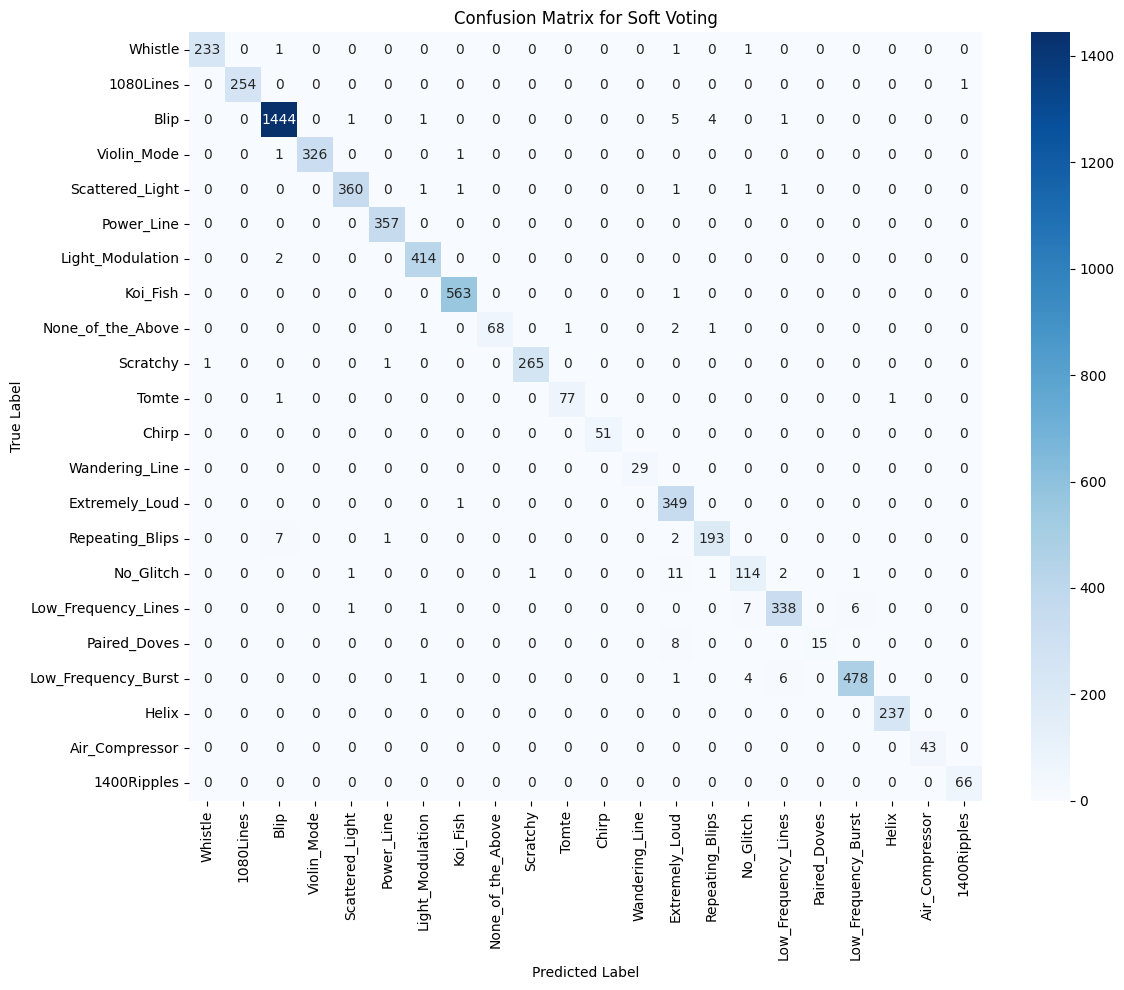

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Generate confusion matrix
cm = confusion_matrix(labels.cpu().numpy(), preds.cpu().numpy())

# Get the actual labels from the inverse label map
inv_label_map = {v: k.decode('utf-8') for k, v in label_map.items()}
sorted_labels = [inv_label_map[i] for i in sorted(inv_label_map.keys())]


# Plot confusion matrix
plt.figure(figsize=(12, 10)) #increased figure size
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=sorted_labels, yticklabels=sorted_labels) #using sorted_labels
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Soft Voting')
plt.xticks(rotation=90) # Rotate x-axis labels
plt.yticks(rotation=0)  # Keep y-axis labels horizontal
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

### Evaluate on Test Set
Now, let's evaluate the soft voting model on the held-out test set to get a realistic estimate of its performance on unseen data.

In [ ]:
test_datasets = [
    SpectrogramDataset(test_df, url_col=f"url{i}", transform=transforms_list[i-1])
    for i in range(1, 5)
]
test_dataloaders = [
    DataLoader(ds, batch_size=32, shuffle=False, num_workers=2)
    for ds in test_datasets
]

test_preds, test_labels = soft_voting_predict(
    models, test_dataloaders, device,
    weights=[0.2535, 0.247, 0.2434, 0.256] # Using the same weights as the training evaluation
)

test_accuracy = (test_preds == test_labels).sum().item() / len(test_labels)
print(f"Soft Voting Accuracy on Test Set: {test_accuracy:.4f}")

# You can also generate a confusion matrix for the test set if you like
# test_cm = confusion_matrix(test_labels.cpu().numpy(), test_preds.cpu().numpy())
# plt.figure(figsize=(12, 10))
# sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues', xticklabels=sorted_labels, yticklabels=sorted_labels)
# plt.xlabel('Predicted Label')
# plt.ylabel('True Label')
# plt.title('Confusion Matrix for Soft Voting (Test Set)')
# plt.xticks(rotation=90)
# plt.yticks(rotation=0)
# plt.tight_layout()
# plt.show()

In [ ]:
#using custom input
import torch
from torchvision import transforms
from PIL import Image

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])
my_img = Image.open("/content/drive/MyDrive/MLxLIGO/testing.png").convert("L")  # grayscale
my_img_tensor = transform(my_img).unsqueeze(0).to(device)

In [ ]:
#running the model through the combination

num_classes=len(label_map)
#putting all the models in eval mode
for model in models:
  model.eval()

#collecting predictions
with torch.no_grad():
  probs = torch.zeros((1,num_classes), device=device)
  for model in models:
    output = model(my_img_tensor)
    probs += torch.softmax(output, dim=1)

  #average probabilites
  probs /= len(models)

  #final
  predicted_class = torch.argmax(probs, dim=1).item()

inv_label_map = {v: k for k, v in label_map.items()}
print("Predicted class:", inv_label_map[predicted_class])
#initially it is stored as
#"Blip": 0
#now we want
#0: "Blip"